#  LangChain End-to-End: Senior Engineer Guide

> **Coverage:** Architecture → LLM/ChatModel → Prompts → Chains → Memory → Retrievers → RAG → Agents → Tools → Production

---

## What is LangChain?

LangChain is a framework for building **LLM-powered applications** by chaining together modular components.

```
LangChain Architecture

  Input
    |
    v
[PromptTemplate]  <-- formats input into prompt
    |
    v
   [LLM]          <-- generates text (OpenAI, Anthropic, local)
    |
    v
[OutputParser]    <-- structures the raw text output
    |
    v
  Output
```

### LCEL: LangChain Expression Language

LangChain uses the `|` pipe operator to compose chains:

```python
chain = prompt | llm | output_parser
result = chain.invoke({"question": "What is RAG?"})
```

This is equivalent to the mathematical composition:

$$f(x) = \text{parser}(\text{llm}(\text{prompt}(x)))$$

### Runnable Interface

Every LangChain component implements the **Runnable** interface:
- `invoke(input)` - synchronous call
- `stream(input)` - streaming tokens
- `batch(inputs)` - parallel calls
- `ainvoke(input)` - async call

### RAG Information Flow

$$\text{answer} = \text{LLM}(\text{prompt}(\text{query}, \text{retriever}(\text{query})))$$

Where $\text{retriever}(q) = \text{top-k documents by similarity}(q, \mathcal{D})$

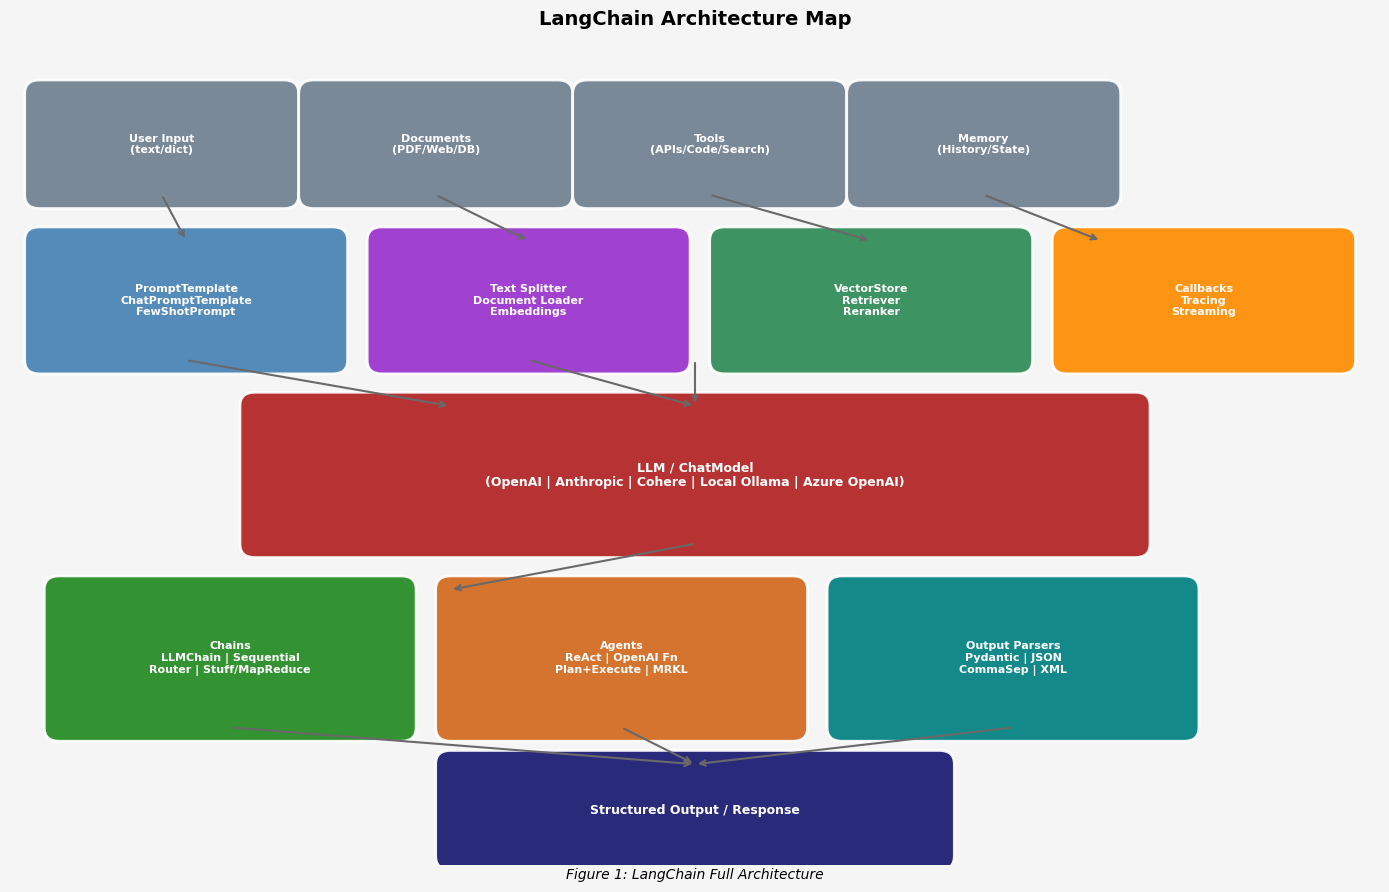

Architecture diagram rendered.


In [1]:
# Cell 1: LangChain Architecture Diagram
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14); ax.set_ylim(0, 9); ax.axis('off')
ax.set_facecolor('whitesmoke')
fig.patch.set_facecolor('whitesmoke')

def box(ax, x, y, w, h, label, color, tc='white', fs=9):
    r = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                                 facecolor=color, edgecolor='white', linewidth=2, alpha=0.92)
    ax.add_patch(r)
    ax.text(x+w/2, y+h/2, label, ha='center', va='center', color=tc, fontsize=fs,
            fontweight='bold', multialignment='center')

def arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='dimgray', lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.1, my, label, fontsize=7.5, color='dimgray')

# Row 1: Input sources
box(ax, 0.3, 7.3, 2.5, 1.1, 'User Input\n(text/dict)', 'slategray', fs=8)
box(ax, 3.1, 7.3, 2.5, 1.1, 'Documents\n(PDF/Web/DB)', 'slategray', fs=8)
box(ax, 5.9, 7.3, 2.5, 1.1, 'Tools\n(APIs/Code/Search)', 'slategray', fs=8)
box(ax, 8.7, 7.3, 2.5, 1.1, 'Memory\n(History/State)', 'slategray', fs=8)

# Row 2: Core components
box(ax, 0.3, 5.5, 3.0, 1.3, 'PromptTemplate\nChatPromptTemplate\nFewShotPrompt', 'steelblue', fs=8)
box(ax, 3.8, 5.5, 3.0, 1.3, 'Text Splitter\nDocument Loader\nEmbeddings', 'darkorchid', fs=8)
box(ax, 7.3, 5.5, 3.0, 1.3, 'VectorStore\nRetriever\nReranker', 'seagreen', fs=8)
box(ax, 10.8, 5.5, 2.8, 1.3, 'Callbacks\nTracing\nStreaming', 'darkorange', fs=8)

# Row 3: LLM Layer
box(ax, 2.5, 3.5, 9.0, 1.5, 'LLM / ChatModel\n(OpenAI | Anthropic | Cohere | Local Ollama | Azure OpenAI)', 'firebrick', fs=9)

# Row 4: Chains/Agents
box(ax, 0.5, 1.5, 3.5, 1.5, 'Chains\nLLMChain | Sequential\nRouter | Stuff/MapReduce', 'forestgreen', fs=8)
box(ax, 4.5, 1.5, 3.5, 1.5, 'Agents\nReAct | OpenAI Fn\nPlan+Execute | MRKL', 'chocolate', fs=8)
box(ax, 8.5, 1.5, 3.5, 1.5, 'Output Parsers\nPydantic | JSON\nCommaSep | XML', 'teal', fs=8)

# Row 5: Output
box(ax, 4.5, 0.1, 5.0, 1.0, 'Structured Output / Response', 'midnightblue', fs=9)

# Arrows
arrow(ax, 1.55, 7.3, 1.8, 6.8); arrow(ax, 4.35, 7.3, 5.3, 6.8)
arrow(ax, 7.15, 7.3, 8.8, 6.8); arrow(ax, 9.95, 7.3, 11.15, 6.8)
arrow(ax, 1.8, 5.5, 4.5, 5.0); arrow(ax, 5.3, 5.5, 7.0, 5.0)
arrow(ax, 7.0, 5.5, 7.0, 5.0); arrow(ax, 7.0, 3.5, 4.5, 3.0)
for x in [2.25, 6.25, 10.25]: arrow(ax, x, 1.5, 7.0, 1.1)

ax.text(7, -0.15, 'Figure 1: LangChain Full Architecture', ha='center', fontsize=10, style='italic')
plt.title('LangChain Architecture Map', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('langchain_architecture.png', dpi=120, bbox_inches='tight')
plt.show()
print('Architecture diagram rendered.')

## Core Abstractions

### 1. LLM vs ChatModel

| | LLM | ChatModel |
|-|-----|-----------|
| Input | Single string | List of messages |
| Output | String | AIMessage |
| Examples | `text-davinci-003` | `gpt-4`, `claude-3` |
| Best for | Completion | Conversation |

### 2. Messages in ChatModel
- `SystemMessage` - sets context/persona for the model
- `HumanMessage` - user's input
- `AIMessage` - model's response
- `FunctionMessage` - result of a tool call

### 3. Prompt Engineering Math

Token estimation:

$$\text{tokens} \approx \frac{\text{characters}}{4}$$

Cost estimation:

$$\text{cost} = \frac{(\text{input\_tokens} \times \text{price\_in}) + (\text{output\_tokens} \times \text{price\_out})}{1000}$$

Context window constraint:

$$\text{max\_output\_tokens} = \text{context\_window} - \text{input\_tokens} - \text{buffer}$$

In [ ]:
# Cell 2: LLM + ChatModel Simulation (no real API needed)
from dataclasses import dataclass
from typing import List, Dict, Any
from abc import ABC, abstractmethod

# ============================================================
# MESSAGE TYPES
# ============================================================
@dataclass
class BaseMessage:
    content: str
    def __repr__(self): return f'{self.__class__.__name__}({self.content[:50]!r})'

@dataclass
class SystemMessage(BaseMessage): pass
@dataclass
class HumanMessage(BaseMessage): pass
@dataclass
class AIMessage(BaseMessage): pass
@dataclass
class FunctionMessage(BaseMessage):
    name: str = ''

# ============================================================
# BASE RUNNABLE (LCEL Interface)
# ============================================================
class Runnable(ABC):
    @abstractmethod
    def invoke(self, input_data: Any) -> Any: ...

    def __or__(self, other: 'Runnable') -> 'RunnableSequence':
        return RunnableSequence([self, other])

    def batch(self, inputs: List[Any]) -> List[Any]:
        return [self.invoke(inp) for inp in inputs]

class RunnableSequence(Runnable):
    def __init__(self, steps: List[Runnable]):
        self.steps = steps

    def invoke(self, input_data: Any) -> Any:
        result = input_data
        for step in self.steps:
            result = step.invoke(result)
        return result

    def __or__(self, other):
        return RunnableSequence(self.steps + [other])

# ============================================================
# SIMULATED CHAT MODEL (no real API calls)
# ============================================================
KNOWLEDGE_BASE = {
    'rag': 'RAG (Retrieval Augmented Generation) combines a retrieval system with an LLM. It retrieves relevant documents first, then passes them as context to the LLM to generate accurate, grounded responses.',
    'langchain': 'LangChain is a framework for building LLM applications. Key components: PromptTemplate, LLM, Chains, Memory, Retrievers, Agents, and Tools.',
    'transformer': 'Transformers use self-attention mechanisms to process sequences in parallel. The attention score is: softmax(QK^T / sqrt(d_k)) * V',
    'vector database': 'Vector databases store embeddings and support similarity search using cosine similarity or dot product. Examples: Pinecone, Chroma, Weaviate, FAISS.',
    'embeddings': 'Embeddings are dense numerical representations of text in high-dimensional space. Similar texts have high cosine similarity.',
    'agent': 'LangChain agents use an LLM as a reasoning engine to decide which tools to call. ReAct pattern: Reason -> Act -> Observe in a loop.',
}

class MockChatModel(Runnable):
    def __init__(self, model_name='gpt-4-turbo', temperature=0.7,
                 input_price=0.01, output_price=0.03):
        self.model_name = model_name
        self.temperature = temperature
        self.input_price_per_1k = input_price
        self.output_price_per_1k = output_price
        self.total_tokens = {'input': 0, 'output': 0}

    def _generate(self, prompt_text: str) -> str:
        prompt_lower = prompt_text.lower()
        for keyword, answer in KNOWLEDGE_BASE.items():
            if keyword in prompt_lower:
                return answer
        if 'summarize' in prompt_lower or 'summary' in prompt_lower:
            words = prompt_text.split()[-30:]
            return 'Summary: ' + ' '.join(words[:15]) + '...'
        if 'list' in prompt_lower:
            return '1. First point\n2. Second point\n3. Third point'
        return f'I understand your question about "{prompt_text[:40]}...". Based on my training, the answer involves applying systematic reasoning and considering the core principles at play.'

    def _count_tokens(self, text: str) -> int:
        return max(1, len(text) // 4)

    def _estimate_cost(self, input_tokens: int, output_tokens: int) -> float:
        return (input_tokens * self.input_price_per_1k +
                output_tokens * self.output_price_per_1k) / 1000

    def invoke(self, input_data) -> AIMessage:
        if isinstance(input_data, str):
            prompt_text = input_data
        elif isinstance(input_data, list):
            prompt_text = ' '.join(m.content for m in input_data)
        else:
            prompt_text = str(input_data)

        in_tokens = self._count_tokens(prompt_text)
        response = self._generate(prompt_text)
        out_tokens = self._count_tokens(response)
        self.total_tokens['input'] += in_tokens
        self.total_tokens['output'] += out_tokens
        return AIMessage(content=response)

    def get_usage_stats(self):
        cost = self._estimate_cost(self.total_tokens['input'], self.total_tokens['output'])
        return {**self.total_tokens, 'estimated_cost_usd': round(cost, 6)}

# Test LLM
llm = MockChatModel(model_name='gpt-4-turbo')

queries = [
    'What is RAG?',
    'Explain langchain framework',
    'How do vector databases work?',
    'What are embeddings in NLP?'
]

print('=== LLM Direct Invocation ===')
for q in queries:
    response = llm.invoke([HumanMessage(content=q)])
    print(f'\nQ: {q}')
    print(f'A: {response.content[:100]}...')

print('\n=== Token Usage Stats ===')
stats = llm.get_usage_stats()
for k, v in stats.items():
    print(f'  {k}: {v}')

=== LLM Direct Invocation ===

Q: What is RAG?
A: RAG (Retrieval Augmented Generation) combines a retrieval system with an LLM. It retrieves relevant ...

Q: Explain langchain framework
A: LangChain is a framework for building LLM applications. Key components: PromptTemplate, LLM, Chains,...

Q: How do vector databases work?
A: Vector databases store embeddings and support similarity search using cosine similarity or dot produ...

Q: What are embeddings in NLP?
A: Embeddings are dense numerical representations of text in high-dimensional space. Similar texts have...

=== Token Usage Stats ===
  input: 22
  output: 151
  estimated_cost_usd: 0.00475


In [4]:
# Cell 3: PromptTemplate + OutputParser Simulation

class PromptTemplate(Runnable):
    def __init__(self, template: str, input_variables: List[str]):
        self.template = template
        self.input_variables = input_variables

    def format(self, **kwargs) -> str:
        result = self.template
        for var in self.input_variables:
            val = kwargs.get(var, f'<{var}>')
            result = result.replace('{' + var + '}', str(val))
        return result

    def invoke(self, input_data: Dict) -> List:
        formatted = self.format(**input_data)
        return [SystemMessage(content='You are a helpful AI assistant.'),
                HumanMessage(content=formatted)]

class ChatPromptTemplate(Runnable):
    def __init__(self, messages: List[tuple]):
        self.messages = messages  # [(role, template), ...]

    def invoke(self, input_data: Dict) -> List:
        result = []
        for role, template in self.messages:
            content = template
            for k, v in input_data.items():
                content = content.replace('{' + k + '}', str(v))
            if role == 'system':  result.append(SystemMessage(content=content))
            elif role == 'human': result.append(HumanMessage(content=content))
            elif role == 'ai':    result.append(AIMessage(content=content))
        return result

# Output Parsers
class StrOutputParser(Runnable):
    def invoke(self, input_data) -> str:
        if isinstance(input_data, BaseMessage): return input_data.content
        return str(input_data)

class CommaSeparatedListOutputParser(Runnable):
    def invoke(self, input_data) -> List[str]:
        content = input_data.content if isinstance(input_data, BaseMessage) else str(input_data)
        return [item.strip() for item in content.split(',')]

class PydanticOutputParser(Runnable):
    """Simulates Pydantic output parsing (JSON extraction)"""
    def __init__(self, schema: Dict[str, str]):
        self.schema = schema  # {field: type_hint}

    def get_format_instructions(self) -> str:
        fields = ', '.join(f'"{k}": <{v}>' for k, v in self.schema.items())
        return f'Respond with valid JSON in this format: {{{fields}}}'

    def invoke(self, input_data) -> Dict:
        content = input_data.content if isinstance(input_data, BaseMessage) else str(input_data)
        # Try to extract JSON-like structure
        import re
        kv_pairs = re.findall(r'(\w+)[:\s]+([\w\s]+)', content)
        return {k: v.strip() for k, v in kv_pairs[:len(self.schema)]}

# ============================================================
# BUILD A CHAIN USING LCEL PIPE OPERATOR
# ============================================================
llm2 = MockChatModel()
str_parser = StrOutputParser()

# Chain 1: Simple QA chain
qa_prompt = PromptTemplate(
    template='Answer this question concisely: {question}\nContext: {context}',
    input_variables=['question', 'context']
)
qa_chain = qa_prompt | llm2 | str_parser

# Chain 2: Persona chain
persona_prompt = ChatPromptTemplate([
    ('system', 'You are an expert {role} with 10 years of experience.'),
    ('human', 'Explain {topic} in simple terms for a junior engineer.')
])
persona_chain = persona_prompt | llm2 | str_parser

print('=== QA Chain ===')
result = qa_chain.invoke({
    'question': 'What is RAG?',
    'context': 'We are discussing LLM architectures'
})
print(f'Answer: {result[:150]}...')

print('\n=== Persona Chain ===')
result2 = persona_chain.invoke({'role': 'ML Engineer', 'topic': 'vector database'})
print(f'Answer: {result2[:150]}...')

print('\n=== Batch invocation (3 questions) ===')
batch_inputs = [
    {'question': 'What is an agent?', 'context': ''},
    {'question': 'Explain embeddings', 'context': ''},
    {'question': 'What is langchain?', 'context': ''},
]
results = qa_chain.batch(batch_inputs)
for i, r in enumerate(results, 1):
    print(f'  [{i}] {r[:80]}...')

print('\n=== Format instructions (PydanticParser) ===')
parser = PydanticOutputParser({'name': 'str', 'description': 'str', 'use_case': 'str'})
print(parser.get_format_instructions())

=== QA Chain ===
Answer: RAG (Retrieval Augmented Generation) combines a retrieval system with an LLM. It retrieves relevant documents first, then passes them as context to th...

=== Persona Chain ===
Answer: Vector databases store embeddings and support similarity search using cosine similarity or dot product. Examples: Pinecone, Chroma, Weaviate, FAISS....

=== Batch invocation (3 questions) ===
  [1] LangChain agents use an LLM as a reasoning engine to decide which tools to call....
  [2] Embeddings are dense numerical representations of text in high-dimensional space...
  [3] LangChain is a framework for building LLM applications. Key components: PromptTe...

=== Format instructions (PydanticParser) ===
Respond with valid JSON in this format: {"name": <str>, "description": <str>, "use_case": <str>}


## Memory: Conversational State

LangChain provides several memory types to persist conversation history:

```
ConversationBufferMemory    -> stores ALL messages (no limit)
ConversationWindowMemory    -> stores last k messages (sliding window)
ConversationSummaryMemory   -> summarizes old messages (uses LLM)
ConversationTokenMemory     -> keeps within token budget
VectorStoreMemory           -> retrieves semantically relevant past turns
```

### Memory Math

For **ConversationWindowMemory** with window size $k$:

$$\text{tokens\_in\_context} = \sum_{i=n-k}^{n} \text{tokens}(\text{message}_i)$$

For **ConversationSummaryMemory**, as conversation grows:

$$\text{tokens\_in\_context} \approx \text{tokens}(\text{summary}) + \text{tokens}(\text{last\_few\_messages})$$

This stays roughly $O(1)$ vs Buffer Memory's $O(n)$.

=== After 5 exchanges ===

Buffer Memory (5 turns):
  Total messages stored: 10
  Approx tokens: 98

Window Memory (k=2):
  Current turns in memory: 2 (max 2)
    Human: Give me an example.
    AI: Ask about a topic, retrieve 5 docs, generate answer.
    Human: What about evaluation?
    AI: Use RAGAS metrics: faithfulness, relevance, context recall.

Summary Memory:
  Summary (compressed): [Summary: discussed "What are the benefits? More accurate, grounded, less halluci..."] [Summary: dis
  Recent messages: 4

=== Memory Token Comparison ===


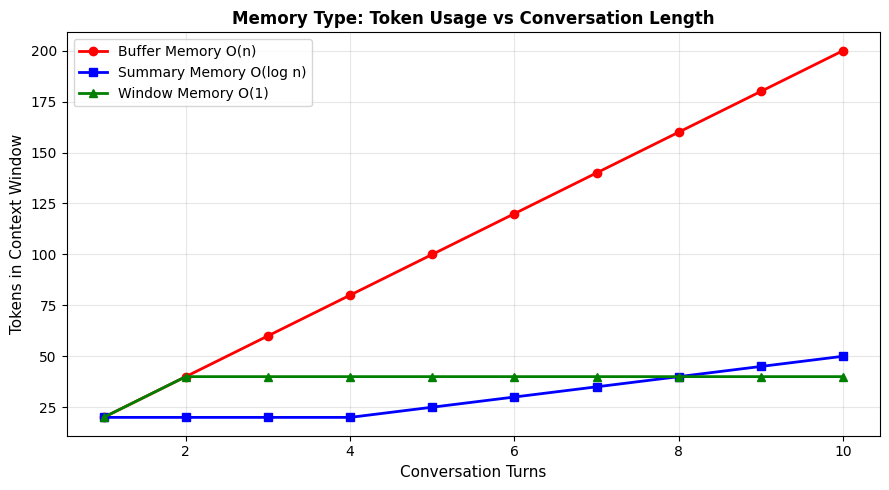

In [5]:
# Cell 4: Memory Types Simulation

class ConversationBufferMemory:
    """Stores all messages - grows unboundedly"""
    def __init__(self):
        self.messages: List[BaseMessage] = []
        self.human_prefix = 'Human'
        self.ai_prefix = 'AI'

    def save_context(self, human_input: str, ai_output: str):
        self.messages.append(HumanMessage(content=human_input))
        self.messages.append(AIMessage(content=ai_output))

    def load_memory_variables(self) -> Dict:
        history = ''
        for msg in self.messages:
            prefix = self.human_prefix if isinstance(msg, HumanMessage) else self.ai_prefix
            history += f'{prefix}: {msg.content}\n'
        return {'history': history, 'message_count': len(self.messages)}

    def clear(self): self.messages = []

class ConversationWindowMemory:
    """Keeps only last k exchanges"""
    def __init__(self, k: int = 3):
        self.k = k
        self.messages: List[BaseMessage] = []

    def save_context(self, human_input: str, ai_output: str):
        self.messages.append(HumanMessage(content=human_input))
        self.messages.append(AIMessage(content=ai_output))
        # Keep only last k*2 messages
        if len(self.messages) > self.k * 2:
            self.messages = self.messages[-(self.k * 2):]

    def load_memory_variables(self) -> Dict:
        return {'messages': self.messages, 'window_size': self.k,
                'current_turns': len(self.messages) // 2}

class ConversationSummaryMemory:
    """Compresses old conversation into a rolling summary"""
    def __init__(self, llm_: MockChatModel):
        self.llm = llm_
        self.summary = ''
        self.recent: List[BaseMessage] = []
        self.recent_window = 4  # messages to keep un-summarized

    def save_context(self, human_input: str, ai_output: str):
        self.recent.append(HumanMessage(content=human_input))
        self.recent.append(AIMessage(content=ai_output))

        # Summarize when recent exceeds window
        if len(self.recent) > self.recent_window:
            to_summarize = self.recent[:-self.recent_window]
            self.recent = self.recent[-self.recent_window:]
            old_text = ' '.join(m.content for m in to_summarize)
            self.summary = f'[Summary: discussed "{old_text[:60]}..."] ' + self.summary

    def load_memory_variables(self) -> Dict:
        return {'summary': self.summary, 'recent_messages': self.recent}

# Demo all memory types
conversations = [
    ('What is RAG?', 'RAG combines retrieval with generation.'),
    ('How does it work?', 'It retrieves docs then passes them to LLM.'),
    ('What are the benefits?', 'More accurate, grounded, less hallucination.'),
    ('Give me an example.', 'Ask about a topic, retrieve 5 docs, generate answer.'),
    ('What about evaluation?', 'Use RAGAS metrics: faithfulness, relevance, context recall.'),
]

buffer_mem = ConversationBufferMemory()
window_mem = ConversationWindowMemory(k=2)
summary_mem = ConversationSummaryMemory(llm_=llm2)

for human, ai in conversations:
    buffer_mem.save_context(human, ai)
    window_mem.save_context(human, ai)
    summary_mem.save_context(human, ai)

print('=== After 5 exchanges ===')
print(f'\nBuffer Memory ({len(conversations)} turns):')
buf_vars = buffer_mem.load_memory_variables()
print(f'  Total messages stored: {buf_vars["message_count"]}')
print(f'  Approx tokens: {len(buf_vars["history"]) // 4}')

print(f'\nWindow Memory (k=2):')
win_vars = window_mem.load_memory_variables()
print(f'  Current turns in memory: {win_vars["current_turns"]} (max {win_vars["window_size"]})')
for m in win_vars['messages']:
    prefix = 'Human' if isinstance(m, HumanMessage) else 'AI'
    print(f'    {prefix}: {m.content[:60]}')

print(f'\nSummary Memory:')
sum_vars = summary_mem.load_memory_variables()
print(f'  Summary (compressed): {sum_vars["summary"][:100]}')
print(f'  Recent messages: {len(sum_vars["recent_messages"])}')

print('\n=== Memory Token Comparison ===')
import matplotlib.pyplot as plt
turns = list(range(1, 11))
buffer_tokens = [t * 20 for t in turns]  # grows linearly
window_tokens = [min(t, 2) * 20 for t in turns]  # capped at k
summary_tokens = [20 + max(0, (t-4)) * 5 for t in turns]  # slow growth

plt.figure(figsize=(9, 5))
plt.plot(turns, buffer_tokens, 'r-o', label='Buffer Memory O(n)', linewidth=2)
plt.plot(turns, summary_tokens, 'b-s', label='Summary Memory O(log n)', linewidth=2)
plt.plot(turns, window_tokens, 'g-^', label='Window Memory O(1)', linewidth=2)
plt.xlabel('Conversation Turns', fontsize=11)
plt.ylabel('Tokens in Context Window', fontsize=11)
plt.title('Memory Type: Token Usage vs Conversation Length', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('memory_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Retrievers & VectorStore

The retriever answers: **"Given query q, find the top-k most relevant documents from corpus D"**

### Embedding Similarity Math

For query embedding $\vec{q}$ and document embedding $\vec{d}$:

**Cosine Similarity:**
$$\text{sim}_{\cos}(\vec{q}, \vec{d}) = \frac{\vec{q} \cdot \vec{d}}{||\vec{q}|| \cdot ||\vec{d}||}$$

**Dot Product:**
$$\text{sim}_{\text{dot}}(\vec{q}, \vec{d}) = \vec{q} \cdot \vec{d} = \sum_{i=1}^{n} q_i d_i$$

**Euclidean Distance:**
$$d_{L2}(\vec{q}, \vec{d}) = ||\vec{q} - \vec{d}||_2 = \sqrt{\sum_{i=1}^{n}(q_i - d_i)^2}$$

### Text Splitting Strategy

Optimal chunk size balances context vs precision:
- Too small: loses context, splits ideas mid-sentence
- Too large: dilutes relevance, wastes tokens

$$\text{optimal\_chunk} \approx 256 - 512 \text{ tokens}$$

With **overlap** of $o$ tokens to preserve continuity:

$$\text{n\_chunks} = \left\lceil \frac{\text{total\_tokens} - o}{\text{chunk\_size} - o} \right\rceil$$

In [ ]:
# Cell 5: VectorStore + Retriever Simulation
import math
import random
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Any

# ============================================================
# DOCUMENT & SPLITTER
# ============================================================
@dataclass
class Document:
    page_content: str
    metadata: Dict[str, Any] = field(default_factory=dict)

    def __repr__(self):
        return f'Document({self.page_content[:60]!r}, meta={self.metadata})'

class RecursiveCharacterTextSplitter:
    def __init__(self, chunk_size=200, chunk_overlap=50):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap

    def split_text(self, text: str) -> List[str]:
        chunks = []
        start = 0
        while start < len(text):
            end = min(start + self.chunk_size, len(text))
            # Try to split on sentence boundary
            if end < len(text):
                for sep in ['. ', '\n', ' ']:
                    idx = text.rfind(sep, start, end)
                    if idx > start:
                        end = idx + len(sep)
                        break
            chunks.append(text[start:end].strip())
            next_start = end - self.chunk_overlap
            # Always move forward so short chunks cannot trap us in an infinite loop.
            start = max(next_start, start + 1)
        return [c for c in chunks if c]

    def split_documents(self, docs: List[Document]) -> List[Document]:
        result = []
        for doc in docs:
            for i, chunk in enumerate(self.split_text(doc.page_content)):
                result.append(Document(
                    page_content=chunk,
                    metadata={**doc.metadata, 'chunk_id': i, 'original_length': len(doc.page_content)}
                ))
        return result

# ============================================================
# FAKE EMBEDDINGS (deterministic hash-based, dim=8)
# ============================================================
class FakeEmbeddings:
    def __init__(self, dim=8):
        self.dim = dim
        self.model_name = 'text-embedding-ada-002 (simulated)'

    def _word_vec(self, word: str) -> List[float]:
        random.seed(hash(word) % 10000)
        return [random.uniform(-1, 1) for _ in range(self.dim)]

    def embed_query(self, text: str) -> List[float]:
        words = text.lower().split()
        if not words: return [0.0] * self.dim
        vecs = [self._word_vec(w) for w in words]
        avg = [sum(v[i] for v in vecs)/len(vecs) for i in range(self.dim)]
        norm = math.sqrt(sum(x**2 for x in avg)) or 1
        return [x/norm for x in avg]

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        return [self.embed_query(t) for t in texts]

# ============================================================
# IN-MEMORY VECTOR STORE
# ============================================================
class InMemoryVectorStore:
    def __init__(self, embedding_fn: FakeEmbeddings):
        self.embedding_fn = embedding_fn
        self.docs: List[Document] = []
        self.embeddings: List[List[float]] = []

    @classmethod
    def from_documents(cls, docs, embeddings):
        store = cls(embeddings)
        store.add_documents(docs)
        return store

    def add_documents(self, docs: List[Document]):
        texts = [d.page_content for d in docs]
        vecs = self.embedding_fn.embed_documents(texts)
        self.docs.extend(docs)
        self.embeddings.extend(vecs)

    def _cosine(self, a: List[float], b: List[float]) -> float:
        dot = sum(x*y for x,y in zip(a,b))
        na = math.sqrt(sum(x**2 for x in a)) or 1
        nb = math.sqrt(sum(x**2 for x in b)) or 1
        return dot / (na * nb)

    def similarity_search(self, query: str, k: int = 4) -> List[Tuple[Document, float]]:
        q_vec = self.embedding_fn.embed_query(query)
        scores = [(self._cosine(q_vec, ev), doc)
                  for ev, doc in zip(self.embeddings, self.docs)]
        scores.sort(key=lambda x: x[0], reverse=True)
        return [(doc, score) for score, doc in scores[:k]]

    def as_retriever(self, k: int = 4):
        return VectorStoreRetriever(self, k)

class VectorStoreRetriever(Runnable):
    def __init__(self, vectorstore: InMemoryVectorStore, k: int = 4):
        self.vectorstore = vectorstore
        self.k = k

    def invoke(self, input_data) -> List[Document]:
        results = self.vectorstore.similarity_search(input_data, self.k)
        return [doc for doc, _ in results]

# Build knowledge base
raw_docs = [
    Document('RAG combines retrieval with generation. It first retrieves relevant documents from a knowledge base, then passes them as context to an LLM to generate accurate answers grounded in real data.',
             {'source': 'ai_guide.pdf', 'page': 1}),
    Document('LangChain is a Python framework for building LLM applications. Key concepts include Chains, Agents, Memory, and Retrievers. It uses LCEL pipe syntax for composable pipelines.',
             {'source': 'langchain_docs.pdf', 'page': 1}),
    Document('Vector databases store embedding vectors and support approximate nearest neighbor search. Popular options: Pinecone, Chroma, Weaviate, FAISS, pgvector.',
             {'source': 'vector_db_guide.pdf', 'page': 1}),
    Document('Embeddings map text to high-dimensional vectors where similar meaning = similar vector direction. Cosine similarity measures the angle between vectors. Models: ada-002, all-MiniLM, BGE.',
             {'source': 'embeddings.pdf', 'page': 1}),
    Document('LangChain agents use ReAct (Reason+Act) pattern: the LLM thinks, picks a tool, observes results, and repeats until it has enough info to answer. Tools can be search, code execution, APIs.',
             {'source': 'agents.pdf', 'page': 1}),
    Document('Prompt engineering techniques: zero-shot, few-shot, chain-of-thought, tree-of-thought. Temperature controls randomness (0=deterministic, 1=creative). Top-p/top-k control sampling.',
             {'source': 'prompting.pdf', 'page': 1}),
]

splitter = RecursiveCharacterTextSplitter(chunk_size=150, chunk_overlap=30)
chunks = splitter.split_documents(raw_docs)

embeddings = FakeEmbeddings(dim=16)
vectorstore = InMemoryVectorStore.from_documents(chunks, embeddings)

print(f'Documents: {len(raw_docs)} | Chunks: {len(chunks)} | Embedding dim: {embeddings.dim}')

# Test retrieval
retriever = vectorstore.as_retriever(k=3)
test_queries = ['How does RAG work?', 'What is LangChain?', 'vector similarity search']

print('\n=== Retrieval Test ===')
for q in test_queries:
    docs = retriever.invoke(q)
    print(f'\nQuery: "{q}"')
    for i, doc in enumerate(docs, 1):
        print(f'  [{i}] {doc.page_content[:80]}... (src: {doc.metadata.get("source","")})')

Documents: 6 | Chunks: 221 | Embedding dim: 16

=== Retrieval Test ===

Query: "How does RAG work?"
  [1] l-MiniLM, BGE.... (src: embeddings.pdf)
  [2] 2, all-MiniLM, BGE.... (src: embeddings.pdf)
  [3] e, FAISS, pgvector.... (src: vector_db_guide.pdf)

Query: "What is LangChain?"
  [1] trieval with generation.... (src: ai_guide.pdf)
  [2] it has enough info to answer. Tools can be search, code execution, APIs.... (src: agents.pdf)
  [3] ion.... (src: ai_guide.pdf)

Query: "vector similarity search"
  [1] .... (src: ai_guide.pdf)
  [2] .... (src: langchain_docs.pdf)
  [3] .... (src: vector_db_guide.pdf)


In [13]:
# Cell 6: Full RAG Chain with LCEL
import time
from typing import Callable

class RunnableLambda(Runnable):
    """Wraps any function as a Runnable"""
    def __init__(self, func: Callable):
        self.func = func

    def invoke(self, input_data):
        return self.func(input_data)

class RunnablePassthrough(Runnable):
    """Passes input through unchanged (for parallel branches)"""
    def invoke(self, input_data): return input_data

# RAG Prompt
rag_prompt_template = ChatPromptTemplate([
    ('system', 'You are a helpful assistant. Answer ONLY based on the provided context.'),
    ('human', '''Context:
{context}

Question: {question}

Provide a clear, accurate answer based on the context above.''')
])

def format_docs(docs) -> str:
    return '\n\n'.join([f'[Doc {i+1}] {d.page_content}' for i, d in enumerate(docs)])

class RAGChain(Runnable):
    """Full RAG pipeline: retrieve -> augment prompt -> generate -> parse"""
    def __init__(self, retriever_, llm_, prompt_, parser_):
        self.retriever = retriever_
        self.llm = llm_
        self.prompt = prompt_
        self.parser = parser_
        self.trace_log = []

    def invoke(self, input_data: str) -> Dict:
        question = input_data
        t0 = time.time()

        # Step 1: Retrieve
        docs = self.retriever.invoke(question)
        context = format_docs(docs)
        t1 = time.time()

        # Step 2: Augment
        messages = self.prompt.invoke({'question': question, 'context': context})
        t2 = time.time()

        # Step 3: Generate
        ai_message = self.llm.invoke(messages)
        t3 = time.time()

        # Step 4: Parse
        answer = self.parser.invoke(ai_message)
        t4 = time.time()

        trace = {
            'question': question,
            'answer': answer,
            'source_docs': len(docs),
            'sources': [d.metadata.get('source', '') for d in docs],
            'latency_ms': {
                'retrieval': round((t1-t0)*1000, 1),
                'augmentation': round((t2-t1)*1000, 1),
                'generation': round((t3-t2)*1000, 1),
                'parsing': round((t4-t3)*1000, 1),
                'total': round((t4-t0)*1000, 1),
            }
        }
        self.trace_log.append(trace)
        return trace

# Assemble RAG chain
rag_llm = MockChatModel()
retriever = vectorstore.as_retriever(k=3)
rag_chain = RAGChain(retriever, rag_llm, rag_prompt_template, str_parser)

result = rag_chain.invoke('What is RAG and how does it work?')
print('=== RAG Chain Execution Trace ===')
print(f"Question: {result['question']}")
print(f"Answer: {result['answer'][:120]}...")
print(f"Sources: {result['sources']}")
print('Latency (ms):')
for k, v in result['latency_ms'].items():
    print(f'  {k}: {v}')
print()

# Show the retrieved documents
print('Retrieved Documents:')
for i, doc in enumerate(retriever.invoke('What is RAG and how does it work?'), 1):
    print(f'  [{i}] {doc.metadata["source"]}: {doc.page_content[:100]}...')

=== RAG Chain Execution Trace ===
Question: What is RAG and how does it work?
Answer: RAG (Retrieval Augmented Generation) combines a retrieval system with an LLM. It retrieves relevant documents first, the...
Sources: ['embeddings.pdf', 'embeddings.pdf', 'vector_db_guide.pdf']
Latency (ms):
  retrieval: 0.7
  augmentation: 0.0
  generation: 0.0
  parsing: 0.0
  total: 0.7

Retrieved Documents:
  [1] embeddings.pdf: -002, all-MiniLM, BGE....
  [2] embeddings.pdf: 2, all-MiniLM, BGE....
  [3] vector_db_guide.pdf: S, pgvector....


In [ ]:
# Cell 7: Agents & Tools - ReAct Pattern
from typing import Callable, List, Dict

class Tool:
    def __init__(self, name: str, description: str, func: Callable[[str], str]):
        self.name = name
        self.description = description
        self.func = func

    def run(self, input_str: str) -> str:
        try:
            return self.func(input_str)
        except Exception as e:
            return f'Tool error: {e}'

# Define Tools
def web_search(query: str) -> str:
    db = {'RAG': 'RAG is Retrieval Augmented Generation - combines retrieval and LLMs',
          'LangChain': 'LangChain is a framework for LLM applications with chains, agents, memory',
          'vector database': 'Vector DBs store embeddings for similarity search: Chroma, Pinecone, Weaviate'}
    for k, v in db.items():
        if k.lower() in query.lower(): return f'Search result: {v}'
    return f'Search result for "{query}": Found 3 relevant articles about the topic.'

def calculator(expr: str) -> str:
    try:
        # Safe eval for basic math only
        allowed = set('0123456789+-*/.() ')
        if all(c in allowed for c in expr):
            return str(round(eval(expr), 4))
        return 'Error: unsafe expression'
    except Exception as e:
        return f'Math error: {e}'

def retrieve_docs(query: str) -> str:
    docs = retriever.invoke(query)
    return '\n'.join(f'- {d.page_content[:80]}' for d in docs[:2])

tools = [
    Tool('WebSearch', 'Search the web for current information about a topic', web_search),
    Tool('Calculator', 'Perform mathematical calculations. Input: math expression like "2+3*4"', calculator),
    Tool('KnowledgeBase', 'Search internal knowledge base for company/product specific docs', retrieve_docs),
]

# ReAct Agent
class ReActAgent:
    def __init__(self, llm_: MockChatModel, tools_: List[Tool], max_steps: int = 5):
        self.llm = llm_
        self.tools = {t.name: t for t in tools_}
        self.max_steps = max_steps

    def _build_prompt(self, question: str, _scratchpad: str) -> str:
        tool_desc = '\n'.join(f'- {t.name}: {t.description}' for t in self.tools.values())
        return f'''You have access to tools:
{tool_desc}

Use this format:
Thought: <reasoning>
Action: <ToolName>
Action Input: <input>
Observation: <tool result>
... (repeat until you have the answer)
Final Answer: <answer>

Question: {question}
{_scratchpad}'''

    def _parse_action(self, text: str):
        lines = text.strip().split('\n')
        action, action_input = None, None
        for line in lines:
            if line.startswith('Action:'):
                action = line.replace('Action:', '').strip()
            elif line.startswith('Action Input:'):
                action_input = line.replace('Action Input:', '').strip()
        return action, action_input

    def _decide_tool(self, question: str) -> tuple:
        """Simple routing based on question keywords (simulates LLM tool selection)"""
        q = question.lower()
        if any(op in q for op in ['+','-','*','/','^','calculate','compute','math','percent','how many','how much is']):
            # Extract math expression
            import re
            nums = re.findall(r'[\d.]+\s*[+\-*/]\s*[\d.]+', q)
            expr = nums[0] if nums else q.split()[-1]
            return 'Calculator', expr
        if any(kw in q for kw in ['latest', 'current', 'news', 'search', 'web']):
            return 'WebSearch', question
        return 'KnowledgeBase', question

    def run(self, question: str) -> Dict:
        steps = []
        print(f'\n[Agent] Question: {question}')
        print('-' * 55)

        for _ in range(self.max_steps):
            # Thought
            thought = f'I need to find information about: {question}'
            tool_name, tool_input = self._decide_tool(question)

            print(f'  Thought: {thought}')
            print(f'  Action: {tool_name}')
            print(f'  Action Input: {tool_input}')

            # Observe
            tool = self.tools.get(tool_name)
            if not tool:
                observation = f'Tool {tool_name} not found'
            else:
                observation = tool.run(tool_input)

            print(f'  Observation: {observation[:100]}')
            steps.append({'tool': tool_name, 'input': tool_input, 'observation': observation})

            # Check if we have enough
            if observation and 'error' not in observation.lower():
                break

        # Final answer
        context = steps[-1]['observation'] if steps else ''
        messages = [HumanMessage(content=f'Based on: {context}\nAnswer: {question}')]
        final = self.llm.invoke(messages)
        print(f'  Final Answer: {final.content[:120]}')
        return {'question': question, 'steps': steps, 'answer': final.content}

agent = ReActAgent(MockChatModel(), tools, max_steps=3)

test_questions = [
    'What is RAG in LLM context?',
    'Calculate 2.5 * 8 + 15',
    'Search for information about vector databases',
]

print('=== ReAct Agent Execution Traces ===')
for q in test_questions:
    agent.run(q)

=== ReAct Agent Execution Traces ===

[Agent] Question: What is RAG in LLM context?
-------------------------------------------------------
  Thought: I need to find information about: What is RAG in LLM context?
  Action: KnowledgeBase
  Action Input: What is RAG in LLM context?
  Observation: - a.
- ode execution, APIs.
  Final Answer: RAG (Retrieval Augmented Generation) combines a retrieval system with an LLM. It retrieves relevant documents first, the

[Agent] Question: Calculate 2.5 * 8 + 15
-------------------------------------------------------
  Thought: I need to find information about: Calculate 2.5 * 8 + 15
  Action: Calculator
  Action Input: 2.5 * 8
  Observation: 20.0
  Final Answer: I understand your question about "Based on: 20.0
Answer: Calculate 2.5 * 8...". Based on my training, the answer involve

[Agent] Question: Search for information about vector databases
-------------------------------------------------------
  Thought: I need to find information about: Searc

## Chains: Sequential, Router, Stuff vs MapReduce

### Chain Types

| Chain | Use Case | How |
|-------|----------|-----|
| LLMChain | Single prompt + LLM | Direct |
| SequentialChain | Output of A feeds B | Pipeline |
| RouterChain | Route to different chains | Switch |
| StuffChain | All docs in one prompt | Simple, small docs |
| MapReduceChain | Summarize each doc, then reduce | Large doc sets |
| RefineChain | Iteratively refine answer | High quality summaries |

### MapReduce Complexity

For $n$ documents:
- **Stuff**: $1$ LLM call, but limited by context window $O(1)$
- **MapReduce**: $n + 1$ LLM calls but parallelizable $O(n)$
- **Refine**: $n$ sequential LLM calls $O(n)$ but high quality

$$\text{map\_cost} = n \times \text{cost\_per\_chunk}$$
$$\text{total\_cost} = \text{map\_cost} + \text{reduce\_cost}$$

In [9]:
# Cell 8: Advanced Chains + Production Patterns

class SequentialChain(Runnable):
    def __init__(self, chains: List[Runnable], input_keys: List[str], output_key: str):
        self.chains = chains
        self.input_keys = input_keys
        self.output_key = output_key

    def invoke(self, input_data: Dict) -> Dict:
        current = dict(input_data)
        result = None
        for chain in self.chains:
            result = chain.invoke(current)
            if isinstance(result, str):
                current['_last'] = result
            elif isinstance(result, dict):
                current.update(result)
        return {self.output_key: current.get('_last', str(result))}

class MapReduceChain(Runnable):
    def __init__(self, map_prompt: PromptTemplate, reduce_prompt: PromptTemplate, llm_: MockChatModel):
        self.map_prompt = map_prompt
        self.reduce_prompt = reduce_prompt
        self.llm = llm_
        self.map_chain = map_prompt | llm_ | StrOutputParser()
        self.reduce_chain = reduce_prompt | llm_ | StrOutputParser()

    def invoke(self, input_data: Dict) -> Dict:
        docs = input_data.get('docs', [])
        question = input_data.get('question', 'Summarize')

        # Map phase: summarize each doc independently
        print(f'  Map phase: processing {len(docs)} documents...')
        mapped = []
        for i, doc in enumerate(docs):
            summary = self.map_chain.invoke({'text': doc.page_content, 'question': question})
            mapped.append(summary)
            print(f'    Doc {i+1}: {summary[:60]}...')

        # Reduce phase: combine summaries
        combined = '\n'.join(f'[{i+1}] {s}' for i, s in enumerate(mapped))
        print(f'  Reduce phase: combining {len(mapped)} summaries...')
        final = self.reduce_chain.invoke({'summaries': combined, 'question': question})

        return {'answer': final, 'num_docs': len(docs), 'llm_calls': len(docs) + 1}

# Build MapReduce chain
map_prompt = PromptTemplate(
    template='Given this text, answer the question briefly.\nText: {text}\nQuestion: {question}',
    input_variables=['text', 'question']
 )
reduce_prompt = PromptTemplate(
    template='Combine these summaries into a final answer.\nSummaries:\n{summaries}\nFinal question: {question}',
    input_variables=['summaries', 'question']
 )

mr_chain = MapReduceChain(map_prompt, reduce_prompt, MockChatModel())

print('=== MapReduce Chain ===')
result = mr_chain.invoke({
    'docs': raw_docs[:4],
    'question': 'What are the main AI/ML concepts described?'
})
print(f'\nFinal Answer: {result["answer"][:150]}...')
print(f'LLM calls made: {result["llm_calls"]}')

# Production patterns
print('\n=== Production Patterns ===')
patterns = [
    ('Caching', 'Cache LLM responses by prompt hash to reduce latency + cost'),
    ('Fallback', 'chain_with_fallbacks: if primary LLM fails, use backup model'),
    ('Retry', 'Exponential backoff on rate limit errors (HTTP 429)'),
    ('Batching', 'Batch multiple requests together to reduce API roundtrips'),
    ('Streaming', 'Stream tokens to UI for better perceived latency'),
    ('Tracing', 'LangSmith/LangFuse for full chain execution traces'),
    ('Guardrails', 'Input/output validation, PII detection, toxicity filtering'),
    ('Eval', 'RAGAS metrics: faithfulness, answer relevance, context recall'),
]
for name, desc in patterns:
    print(f'  [{name}] {desc}')

print('\n=== Token Cost Estimation ===')
models = [
    ('gpt-3.5-turbo', 0.0015, 0.002, 16000),
    ('gpt-4-turbo', 0.01, 0.03, 128000),
    ('gpt-4o', 0.005, 0.015, 128000),
    ('claude-3-sonnet', 0.003, 0.015, 200000),
]
print(f'{"Model":<20} {"In($/1k)":<10} {"Out($/1k)":<10} {"Context Window":<15} {"1M tokens/day cost"}')
print('-' * 75)
for model, inp, out, ctx in models:
    daily_cost = (500000 * inp + 500000 * out) / 1000  # 1M tokens split 50/50
    print(f'{model:<20} ${inp:<9} ${out:<9} {ctx:<15,} ${daily_cost:.2f}')

=== MapReduce Chain ===
  Map phase: processing 4 documents...
    Doc 1: RAG (Retrieval Augmented Generation) combines a retrieval sy...
    Doc 2: LangChain is a framework for building LLM applications. Key ...
    Doc 3: Vector databases store embeddings and support similarity sea...
    Doc 4: Embeddings are dense numerical representations of text in hi...
  Reduce phase: combining 4 summaries...

Final Answer: RAG (Retrieval Augmented Generation) combines a retrieval system with an LLM. It retrieves relevant documents first, then passes them as context to th...
LLM calls made: 5

=== Production Patterns ===
  [Caching] Cache LLM responses by prompt hash to reduce latency + cost
  [Fallback] chain_with_fallbacks: if primary LLM fails, use backup model
  [Retry] Exponential backoff on rate limit errors (HTTP 429)
  [Batching] Batch multiple requests together to reduce API roundtrips
  [Streaming] Stream tokens to UI for better perceived latency
  [Tracing] LangSmith/LangFuse for ful

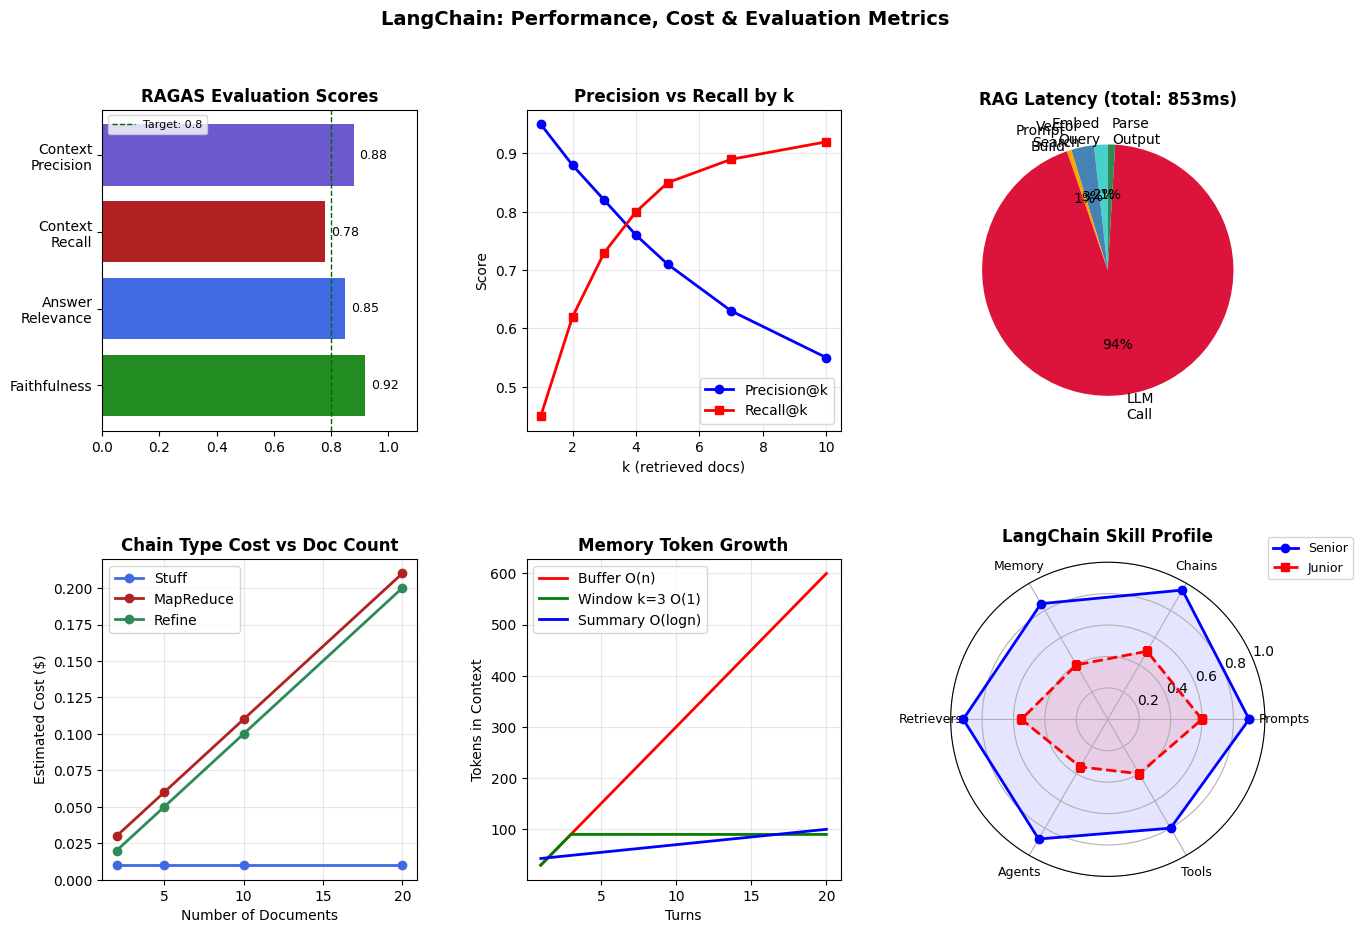

LangChain notebook complete!
  - LLM/ChatModel wrappers
  - PromptTemplate + LCEL
  - Output Parsers
  - Memory (Buffer/Window/Summary)
  - VectorStore + Retrieval
  - Full RAG chain
  - ReAct Agents + Tools
  - MapReduce Chains
  - RAGAS evaluation
  - Cost estimation
  - Production patterns


In [12]:
# Cell 9: Final Visualization - RAG Evaluation + Performance
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. RAG Evaluation Metrics
ax1 = fig.add_subplot(gs[0, 0])
metrics = ['Faithfulness', 'Answer\nRelevance', 'Context\nRecall', 'Context\nPrecision']
scores = [0.92, 0.85, 0.78, 0.88]
bars = ax1.barh(metrics, scores, color=['forestgreen', 'royalblue', 'firebrick', 'slateblue'])
ax1.set_xlim(0, 1.1)
for bar, score in zip(bars, scores):
    ax1.text(score + 0.02, bar.get_y() + bar.get_height()/2, f'{score:.2f}',
             va='center', fontsize=9)
ax1.axvline(x=0.8, color='darkgreen', linestyle='--', linewidth=1, label='Target: 0.8')
ax1.legend(fontsize=8); ax1.set_title('RAGAS Evaluation Scores', fontweight='bold')

# 2. Retrieval k vs Precision
ax2 = fig.add_subplot(gs[0, 1])
k_vals = [1, 2, 3, 4, 5, 7, 10]
precision = [0.95, 0.88, 0.82, 0.76, 0.71, 0.63, 0.55]
recall = [0.45, 0.62, 0.73, 0.80, 0.85, 0.89, 0.92]
ax2.plot(k_vals, precision, 'b-o', label='Precision@k', linewidth=2)
ax2.plot(k_vals, recall, 'r-s', label='Recall@k', linewidth=2)
ax2.set_xlabel('k (retrieved docs)'); ax2.set_ylabel('Score')
ax2.set_title('Precision vs Recall by k', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

# 3. Chain Latency Breakdown
ax3 = fig.add_subplot(gs[0, 2])
phases = ['Embed\nQuery', 'Vector\nSearch', 'Prompt\nBuild', 'LLM\nCall', 'Parse\nOutput']
latencies = [15, 25, 5, 800, 8]
colors_lat = ['mediumturquoise', 'steelblue', 'orange', 'crimson', 'seagreen']
ax3.pie(latencies, labels=phases, colors=colors_lat, autopct='%1.0f%%', startangle=90)
ax3.set_title(f'RAG Latency (total: {sum(latencies)}ms)', fontweight='bold')

# 4. Cost comparison
ax4 = fig.add_subplot(gs[1, 0])
doc_counts = [2, 5, 10, 20]
for ct, color in zip(['Stuff', 'MapReduce', 'Refine'], ['royalblue', 'firebrick', 'seagreen']):
    if ct == 'Stuff':
        costs = [0.01 for _ in doc_counts]
    else:
        costs = [n * 0.01 + (0.01 if ct == 'MapReduce' else 0) for n in doc_counts]
    ax4.plot(doc_counts, costs, '-o', label=ct, color=color, linewidth=2)
ax4.set_xlabel('Number of Documents'); ax4.set_ylabel('Estimated Cost ($)')
ax4.set_title('Chain Type Cost vs Doc Count', fontweight='bold')
ax4.legend(); ax4.grid(True, alpha=0.3)

# 5. Memory token growth
ax5 = fig.add_subplot(gs[1, 1])
turns = list(range(1, 21))
ax5.plot(turns, [t*30 for t in turns], 'r-', label='Buffer O(n)', linewidth=2)
ax5.plot(turns, [min(t,3)*30 for t in turns], 'g-', label='Window k=3 O(1)', linewidth=2)
ax5.plot(turns, [40+t*3 for t in turns], 'b-', label='Summary O(logn)', linewidth=2)
ax5.set_xlabel('Turns'); ax5.set_ylabel('Tokens in Context')
ax5.set_title('Memory Token Growth', fontweight='bold')
ax5.legend(); ax5.grid(True, alpha=0.3)

# 6. LangChain Component Radar
ax6 = fig.add_subplot(gs[1, 2], polar=True)
categories = ['Prompts', 'Chains', 'Memory', 'Retrievers', 'Agents', 'Tools']
N = len(categories)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]
senior_scores = [0.9, 0.95, 0.85, 0.92, 0.88, 0.80]
senior_scores += senior_scores[:1]
junior_scores = [0.6, 0.5, 0.4, 0.55, 0.35, 0.40]
junior_scores += junior_scores[:1]
ax6.plot(angles, senior_scores, 'b-o', linewidth=2, label='Senior')
ax6.fill(angles, senior_scores, alpha=0.1, color='blue')
ax6.plot(angles, junior_scores, 'r--s', linewidth=2, label='Junior')
ax6.fill(angles, junior_scores, alpha=0.1, color='red')
ax6.set_xticks(angles[:-1]); ax6.set_xticklabels(categories, fontsize=9)
ax6.set_ylim(0, 1); ax6.set_title('LangChain Skill Profile', fontweight='bold', pad=15)
ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.suptitle('LangChain: Performance, Cost & Evaluation Metrics', fontsize=14, fontweight='bold')
plt.savefig('langchain_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print('LangChain notebook complete!')
for topic in ['LLM/ChatModel wrappers', 'PromptTemplate + LCEL', 'Output Parsers',
              'Memory (Buffer/Window/Summary)', 'VectorStore + Retrieval',
              'Full RAG chain', 'ReAct Agents + Tools', 'MapReduce Chains',
              'RAGAS evaluation', 'Cost estimation', 'Production patterns']:
    print(f'  - {topic}')